# ClearPath DQR + Cleaning Pipeline

**Data Source**: Docker MySQL `clearpath` (loaded by `database_build.ipynb`)

**Structure**: Executive Summary → Data Profiling → Quality Dimensions → Anomaly Detection → DQ Score → Cleaning Pipeline → Action Items → Appendix

**Target ML**: Busyness prediction (time series + user reports)

---
## Part 0: Configuration & DB Connection

In [ ]:
import sys
import pandas as pd
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Paths (absolute — kernel cwd is project root)
PROJECT_ROOT = Path('/Users/alex/Documents/COMP47360-Research_Practicum/Group6_Summer-Project')
TEST_ROOT = PROJECT_ROOT / 'Data+ML' / 'test'
OUTPUT_DIR = TEST_ROOT / '6.8-6.12_DB' / 'tests' / 'output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(TEST_ROOT))

# ── Simplified to only 3 modules ──
DQR_TABLES = (
    'venues', 'restroom_profiles', 'healthcare_profiles', 'emergency_assets',
    'pedestrian_ramps', 'venue_source_links', 'busyness_scores',
    'external_context_cache', 'user_reports',
)

# dqr_checks.py: quality checks + profiling + cleaning + scoring + improvement suggestions
from dqr.dqr_checks import (
    DQ_WEIGHTS,
    # Quality checks (4 items)
    check_completeness, check_accuracy, check_database_integrity, check_fk_orphans,
    # Six-dimension scoring
    compute_dq_scores, compute_total_score,
    # Data profiling
    build_all_profiles, build_record_analysis,
    # Anomaly detection
    detect_coordinate_anomalies, detect_gps_duplicates,
    # Cleaning
    clean_venues,
    # Improvement suggestions + ML assessment
    build_action_items, assess_ml_usability,
)

# dqr_utils.py: DB connection + geo tools + external APIs
from dqr.dqr_utils import (
    MANHATTAN_BOUNDS, get_conn, is_manhattan, validate_coords, gps_to_district,
    fetch_traffic_hourly, clean_traffic, fetch_and_clean_weather,
)

# dqr_io.py: SQL queries + CSV export
from dqr.dqr_io import query_table, load_dqr_tables, export_dqr_artifacts, build_audit_report

print(f'Project: {PROJECT_ROOT}  |  Output: {OUTPUT_DIR}')
print(f'Started: {datetime.now():%Y-%m-%d %H:%M}')

---
## 1. Executive Summary

In [ ]:
# Call underlying functions directly, no pipeline layer needed
conn = get_conn()
data = load_dqr_tables(conn, DQR_TABLES)
conn.close()

df_venues = data.get('venues', pd.DataFrame())
total_rows = sum(len(df) for df in data.values() if not df.empty)
tables_loaded = sum(1 for df in data.values() if not df.empty)
completeness = round(100 - df_venues.isnull().mean().mean() * 100, 1)
venue_types = df_venues['venue_type'].value_counts().to_dict() if 'venue_type' in df_venues.columns else {}

print(f'={"="*58}')
print('  EXECUTIVE SUMMARY — ClearPath DQR')
print(f'  DB: clearpath (Docker MySQL)')
print(f'  Total lines: {total_rows:,}  |  Tables loaded: {tables_loaded}/{len(DQR_TABLES)}')
print(f'  Venue: {len(df_venues):,}  |  Type: {venue_types}')
print(f'  Completeness: {completeness:.1f}%  |  Date: {datetime.now():%Y-%m-%d}')
print(f'={"="*58}')

---
## 2. Data Profiling

In [ ]:
all_profiles = build_all_profiles(data)  # Profile all table columns; returns a DataFrame with stats and quality metrics per field.
record_analysis = build_record_analysis(df_venues) # Record-level analysis for venues; returns a DataFrame with quality scores and metrics per record.

print(f'Column profiling: {len(all_profiles)} fields across {tables_loaded} tables')
if not all_profiles.empty:
    display(all_profiles.head(10))

if not record_analysis.empty:
    quality_values = record_analysis['record_quality_score']
    print(f'Record quality: mean={quality_values.mean():.2f}, min={quality_values.min():.2f}, '
          f'low(<0.5)={(quality_values < 0.5).sum()}')

---
## 3. Data Quality Dimensions

In [ ]:
# ── Call each check function directly ──
completeness_result = check_completeness(data)
accuracy_result = check_accuracy(df_venues)
integrity_result = check_database_integrity(df_venues)

for name, result in [('completeness', completeness_result),
                     ('accuracy', accuracy_result),
                     ('integrity', integrity_result)]:
    status = 'PASS' if result['passed'] else 'FAIL'
    issues = f'  issues={result["issues"]}' if result['issues'] else ''
    print(f'  {name:<15} score={result["score"]:>6.1f}  {status}{issues}')

# Coordinate validation mask for downstream use
coord_valid_mask = accuracy_result.get('_coord_valid_mask')

print('\nCompleteness detail:')
print(completeness_result['_dataframe'].to_string(index=False))

---
## 4. Anomaly Detection

In [ ]:
anomaly_df = detect_coordinate_anomalies(data) # Detect out-of-bounds coordinates
gps_duplicates_df = detect_gps_duplicates(data, threshold_m=10) # Detect GPS duplicates (10m threshold)

print(f'Anomalies: {len(anomaly_df)}')
if not anomaly_df.empty:
    print(anomaly_df['type'].value_counts().to_string())

print(f'GPS duplicates (<10m): {len(gps_duplicates_df)} pairs')
if not gps_duplicates_df.empty:
    display(gps_duplicates_df.head(5))

---
## 5. DQ Score & Rating


In [ ]:
# Fix borough (if coordinates are in Manhattan but borough ≠ Manhattan, correct it)
if 'borough' in df_venues.columns and 'latitude' in df_venues.columns:
    fixed = 0
    for idx, row in df_venues.iterrows():
        if pd.notna(row.get('latitude')) and pd.notna(row.get('longitude')):
            if is_manhattan(float(row['latitude']), float(row['longitude'])):
                if row.get('borough') != 'Manhattan':
                    df_venues.at[idx, 'borough'] = 'Manhattan'
                    fixed += 1
    if fixed > 0:
        print(f'Borough: fixed {fixed} records → Manhattan')

# Compute six-dimension scores
scores = compute_dq_scores(df_venues, data, anomaly_df, gps_duplicates_df, coord_valid_mask)
total_score, grade = compute_total_score(scores)

print('DQ SCORE & RATING')
print(f'{"Dimension":<18} {"Weight":>7} {"Score":>7} {"Weighted":>8}')
print('-' * 42)
for dimension in DQ_WEIGHTS:
    s = scores[dimension]
    print(f'{dimension:<18} {DQ_WEIGHTS[dimension]:>6.0%} {s:>7.1f} '
          f'{s * DQ_WEIGHTS[dimension]:>8.1f}')
print('-' * 42)
print(f'{"TOTAL":<18} {"100%":>7} {total_score:>7.1f}')
print(f'Rating: {grade} ({total_score:.1f}/100)')

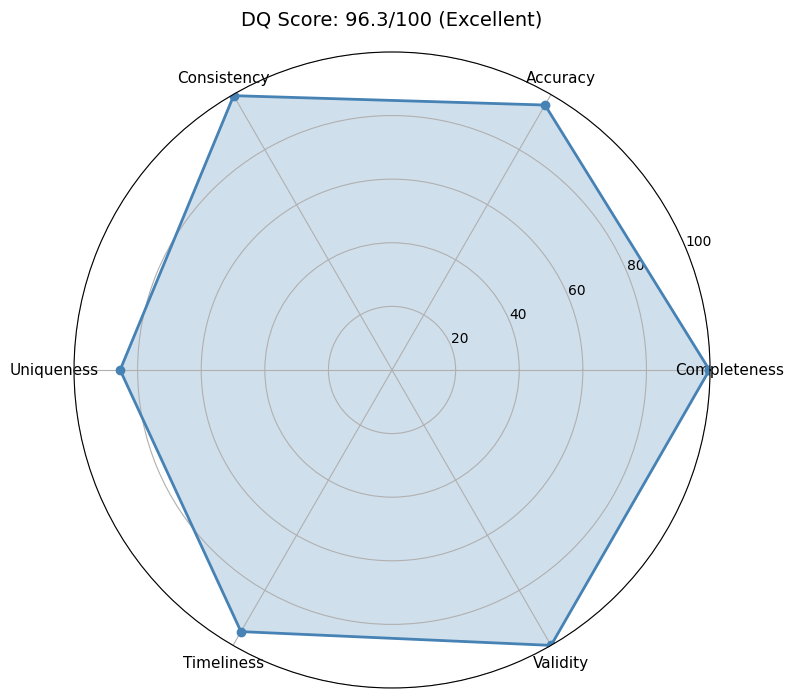

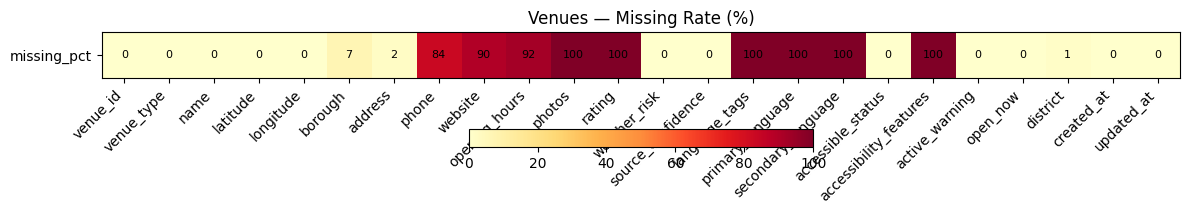

In [7]:
# Radar chart
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
dimensions = list(scores)
values = [scores[name] for name in dimensions]
angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
values_plot = values + [values[0]]
angles += angles[:1]
ax.fill(angles, values_plot, alpha=0.25, color='steelblue')
ax.plot(angles, values_plot, 'o-', color='steelblue', linewidth=2)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(dimensions, size=11)
ax.set_ylim(0, 100)
ax.set_title(f'DQ Score: {total_score:.1f}/100 ({grade})', size=14, pad=20)
plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_dimension_scores.png', dpi=150); plt.show()

# Missing rate heatmap
venue_profile = all_profiles[all_profiles['table'] == 'venues'].copy()
if not venue_profile.empty:
    fig, ax = plt.subplots(figsize=(12, 2))
    missing_values = venue_profile['missing_pct'].to_numpy()[None, :]
    image = ax.imshow(missing_values, cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
    ax.set_xticks(range(len(venue_profile)), labels=venue_profile['column'], rotation=45, ha='right')
    ax.set_yticks([0], labels=['missing_pct'])
    for column_index, value in enumerate(missing_values[0]):
        ax.text(column_index, 0, f'{value:.0f}', ha='center', va='center', fontsize=8)
    fig.colorbar(image, ax=ax, orientation='horizontal', pad=0.45)
    ax.set_title('Venues — Missing Rate (%)')
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_missing_heatmap.png', dpi=150); plt.show()

---
## 6. Cleaning Pipeline & External Data

  Coords: removed 0 invalid records (cached mask)
  Kept: 4838 records (quality_score mean=1.00)
venues_clean: 4838 records


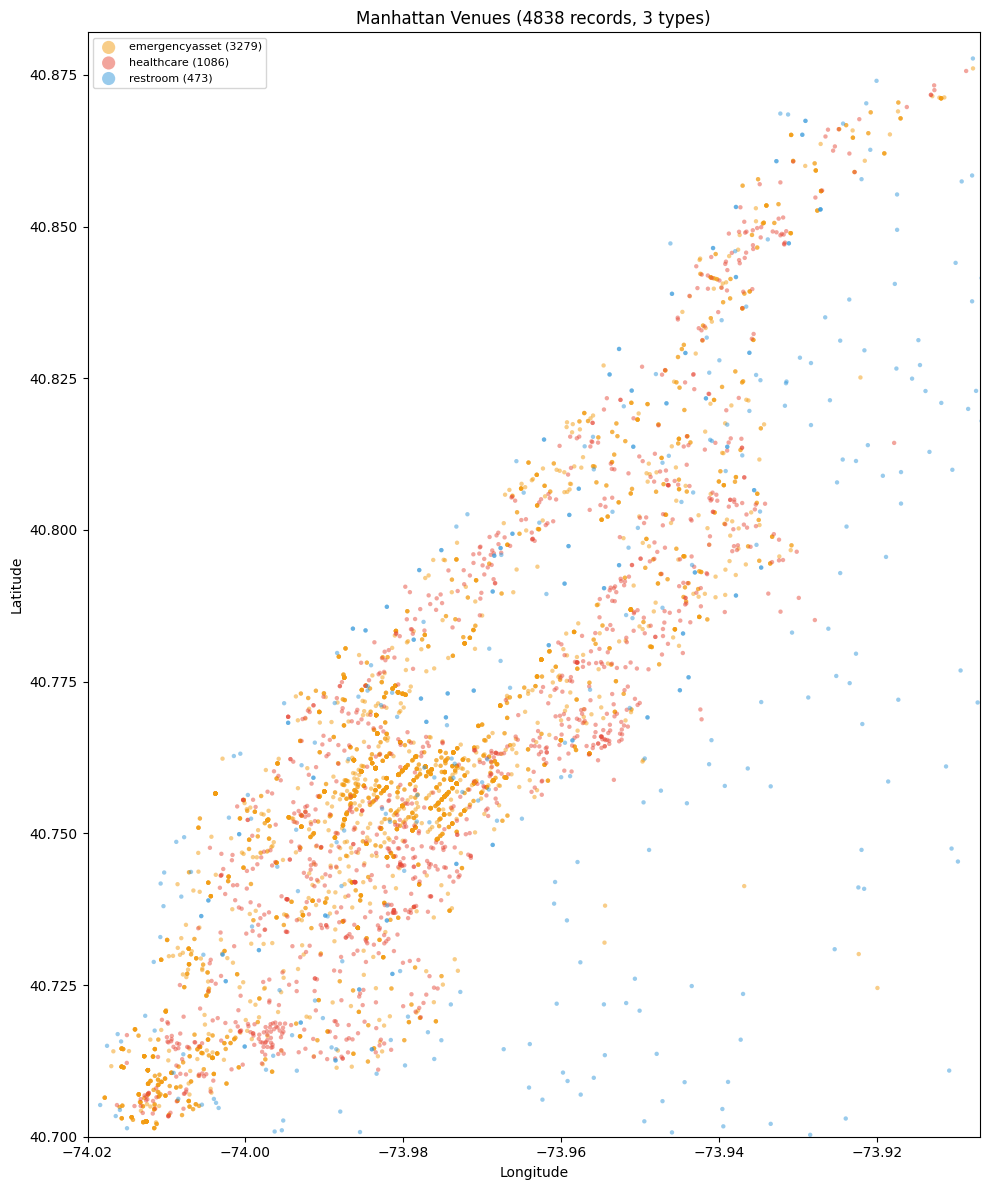

In [8]:
quality_scores = record_analysis['record_quality_score'] if not record_analysis.empty else None
venues_clean = clean_venues(df_venues, coord_valid_mask=coord_valid_mask, quality_scores=quality_scores)
print(f'venues_clean: {len(venues_clean)} records')

if not venues_clean.empty and 'latitude' in venues_clean.columns:
    fig, ax = plt.subplots(figsize=(10, 12))
    colors = {'emergencyasset': '#f39c12', 'healthcare': '#e74c3c', 'restroom': '#3498db'}
    for venue_type in sorted(venues_clean['venue_type'].unique()):
        subset = venues_clean[venues_clean['venue_type'] == venue_type]
        ax.scatter(subset['longitude'], subset['latitude'], c=colors.get(venue_type, '#95a5a6'),
                   label=f'{venue_type} ({len(subset)})', alpha=0.5, s=10, edgecolors='none')
    ax.set(xlabel='Longitude', ylabel='Latitude',
           title=f'Manhattan Venues ({len(venues_clean)} records, '
                 f'{venues_clean["venue_type"].nunique()} types)',
           xlim=(MANHATTAN_BOUNDS['lng_min'], MANHATTAN_BOUNDS['lng_max']),
           ylim=(MANHATTAN_BOUNDS['lat_min'], MANHATTAN_BOUNDS['lat_max']))
    ax.legend(fontsize=8, markerscale=3)
    plt.tight_layout(); plt.savefig(OUTPUT_DIR / 'dqr_venue_scatter.png', dpi=150); plt.show()

In [ ]:
# External data: traffic + weather (fail gracefully)
try:
    traffic_clean = clean_traffic(fetch_traffic_hourly(year=2025))
except Exception as e:
    traffic_clean = pd.DataFrame()
    print(f'Traffic error: {e}')

try:
    weather_clean = fetch_and_clean_weather(raise_errors=True)
except Exception as e:
    weather_clean = pd.DataFrame()
    print(f'Weather error: {e}')

print(f'Traffic rows: {len(traffic_clean)} | Weather rows: {len(weather_clean)}')

---
## 7. Action Items & Appendix

In [ ]:
# ── Action Items ──
actions_df = build_action_items(df_venues, data, scores)
print('=== Action Items ===')
display(actions_df)

# ── Export CSVs ──
export_dqr_artifacts(
    OUTPUT_DIR, venues_clean=venues_clean, traffic_clean=traffic_clean,
    weather_clean=weather_clean, field_summary=all_profiles,
    record_analysis=record_analysis, anomalies=anomaly_df, gps_duplicates=gps_duplicates_df,
)

# ── ML Usability ──
ml = assess_ml_usability(venues_clean, traffic_clean, weather_clean, scores, grade)
print(f'\n{"="*50}')
print(f'  ML USABILITY: {ml["venues_count"]} venues, {ml["coord_complete_pct"]:.0f}% coords, '
      f'{ml["district_count"]}/4 districts, DQ={total_score:.1f}/100')
print(f'{"="*50}')

## Part 8 — Busyness Data Overview

Data imported by `busyness_ingestion.py`.

**Data Scale**: `busyness_scores` table is a Cartesian product of **all venues × 24 hours** (currently 4,780 venues × 24h = 114,720 rows).
Each row contains `score`, `level`, `forecast_1h` (12-hour rolling forecast window), etc. for that venue-hour.

**Training Goal**: Use this data to train a model that predicts each venue's **12-hour continuous values** (busyness score 0-100),
providing the frontend with hourly busyness forecasts and "best time to visit" recommendations.

**Related Files**:
| File | Purpose |
|------|---------|
| `dqr/busyness_ingestion.py` | Core ingestion pipeline (district-level, wktgeom→WGS84→gps_to_district) |
| `tests/test_busyness_ingestion.py` | 43+ pytest test cases |
| `tests/conftest.py` | Updated sys.path to include dqr directory |
| `../../6.2-6.5_DB/clearpath_sources.json` | Added Busyness data source entry |

In [ ]:
# ── 8.1: Busyness Data Overview ──
# Re-establish connection (previous conn may have been closed)
try:
    conn.ping(reconnect=True)
except Exception:
    conn = get_conn()
    print('Reconnected to MySQL')

busyness_count = pd.read_sql('SELECT COUNT(*) as cnt FROM busyness_scores', conn).iloc[0, 0]
venue_count = pd.read_sql('SELECT COUNT(DISTINCT venue_id) as cnt FROM busyness_scores', conn).iloc[0, 0]
district_count = pd.read_sql(
    """SELECT COUNT(DISTINCT v.district) as cnt
       FROM busyness_scores b JOIN venues v ON b.venue_id = v.venue_id""",
    conn
).iloc[0, 0]
model_ver = pd.read_sql(
    "SELECT DISTINCT model_version FROM busyness_scores", conn
)['model_version'].tolist()

print(f'busyness_scores: {busyness_count} rows, {venue_count} venues, {district_count} districts')
print(f'model_versions: {model_ver}')

In [ ]:
# ── 8.2: Busyness Level Distribution ──
level_dist = pd.read_sql(
    'SELECT level, COUNT(*) as cnt FROM busyness_scores GROUP BY level ORDER BY cnt DESC',
    conn
)
print('Busyness level distribution:')
display(level_dist)

fig, ax = plt.subplots(figsize=(6, 4))
colors = {'quiet': '#22c55e', 'moderate': '#eab308', 'busy': '#ef4444', 'no_data': '#94a3b8'}
bars = ax.bar(level_dist['level'], level_dist['cnt'],
              color=[colors.get(l, '#666') for l in level_dist['level']])
for bar, cnt in zip(bars, level_dist['cnt']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(cnt), ha='center', fontsize=10)
ax.set_title('Busyness Level Distribution')
ax.set_ylabel('Row Count')
plt.tight_layout()
plt.show()

In [ ]:
# ── 8.3: Per-District Venue Count + Average Score ──
district_stats = pd.read_sql("""
    SELECT v.district, COUNT(DISTINCT b.venue_id) as venue_count,
           ROUND(AVG(b.score), 1) as avg_score,
           SUM(CASE WHEN b.level = 'busy' THEN 1 ELSE 0 END) as busy_count
    FROM busyness_scores b
    JOIN venues v ON b.venue_id = v.venue_id
    WHERE v.district IS NOT NULL
    GROUP BY v.district
    ORDER BY avg_score DESC
""", conn)
print('Per-district busyness statistics:')
display(district_stats)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: venue count per district
axes[0].barh(district_stats['district'], district_stats['venue_count'], color='#3b82f6')
axes[0].set_title('Venues with Busyness Data')
axes[0].set_xlabel('Venue Count')

# Right: avg score per district
axes[1].barh(district_stats['district'], district_stats['avg_score'], color='#f59e0b')
axes[1].set_title('Average Busyness Score')
axes[1].set_xlabel('Avg Score (0-100)')
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

In [ ]:
# ── 8.4: 12-Hour Busyness Forecast Curves (expanded from forecast_1h JSON) ──
import json as _json

sample_raw = pd.read_sql("""
    SELECT b.venue_id, v.name, v.district, b.score, b.level,
           b.forecast_1h, b.forecast_start_time
    FROM busyness_scores b
    JOIN venues v ON b.venue_id = v.venue_id
    WHERE v.district IN ('midtown_east', 'downtown')
    ORDER BY v.district, b.venue_id
    LIMIT 10
""", conn)

# Expand forecast_1h JSON into one row per hour
rows = []
for _, row in sample_raw.iterrows():
    if row['forecast_1h']:
        forecast = _json.loads(row['forecast_1h'])
        for f in forecast:
            rows.append({
                'venue_id': row['venue_id'],
                'name': row['name'][:30],
                'district': row['district'],
                'offset_hours': f['offset_hours'],
                'percent': f['percent'],
                'level': f['level'],
            })

sample_venues = pd.DataFrame(rows)

if not sample_venues.empty:
    # Pick one representative venue per district
    plot_venues = []
    seen_districts = set()
    for vid in sample_venues['venue_id'].unique():
        sub = sample_venues[sample_venues['venue_id'] == vid]
        d = sub.iloc[0]['district']
        if d not in seen_districts:
            plot_venues.append(vid)
            seen_districts.add(d)
        if len(plot_venues) >= 4:
            break

    # Use different colors for each venue
    palette = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
    fig, ax = plt.subplots(figsize=(12, 5))
    venue_info = []
    for i, vid in enumerate(plot_venues):
        sub = sample_venues[sample_venues['venue_id'] == vid]
        name = sub.iloc[0]['name']
        district = sub.iloc[0]['district']
        short = name[:22] + '...' if len(name) > 22 else name
        label = f"[{district}] {short}"
        color = palette[i % len(palette)]
        ax.plot(sub['offset_hours'], sub['percent'], marker='o', markersize=4,
                color=color, linewidth=2, label=label)
        venue_info.append(f"  {i+1}. {name} ({district})")

    ax.axhline(y=70, color='red', linestyle='--', alpha=0.6, linewidth=1, label='busy (≥70)')
    ax.axhline(y=30, color='orange', linestyle='--', alpha=0.6, linewidth=1, label='moderate (≥30)')
    ax.set_title('12-Hour Forecast Pattern — Sample Venues (per district)')
    ax.set_xlabel('Offset Hours (from now)')
    ax.set_ylabel('Score (0-100)')
    ax.set_xticks(range(0, 12))
    ax.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1.01, 1))
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.show()

    print('Plotted venues:')
    print('\n'.join(venue_info))
else:
    print('No venue-level forecast data available')

In [ ]:
# ── 8.5: Forecast JSON Preview ──
import json as _json2

forecast_sample = pd.read_sql("""
    SELECT b.venue_id, v.name, v.district, b.score, b.level,
           b.forecast_1h, b.model_version, b.created_at
    FROM busyness_scores b
    JOIN venues v ON b.venue_id = v.venue_id
    LIMIT 5
""", conn)

print('Sample busyness_scores rows:')
display(forecast_sample[['venue_id', 'name', 'district', 'score', 'level', 'model_version', 'created_at']])

# Parse the first forecast_1h JSON
if not forecast_sample.empty:
    first_forecast = forecast_sample.iloc[0]['forecast_1h']
    if first_forecast:
        forecast_data = _json2.loads(first_forecast)
        print(f"\nforecast_1h sample (venue: {forecast_sample.iloc[0]['name'][:30]}):")
        for f in forecast_data:
            print(f"  +{f['offset_hours']}h: {f['percent']}% ({f['level']})")

### Part 8 Summary

**Data Source**: NYC SODA Traffic API (7ym2-wayt) — 2025 Manhattan traffic flow
**Transformation Chain**: wktgeom (EPSG:2263) → pyproj → WGS84 → gps_to_district → aggregated by district+hour
**Model Version**: `nyc_traffic_baseline_v1`
**Granularity**: District-level (all venues in the same district share the same score)
**Coverage**: 28/28 segments (100%) → 4,714 venues across 4 districts (100%)

**Known Limitations**:
- All venues in the same district share identical scores (not venue-specific)
- 28 traffic segments cannot distinguish venue-level differences
- `estimated_wait_minutes` set to NULL (historical traffic cannot infer venue wait times)
- Will be overwritten by BestTime API (real-time telemetry) at venue level

**Acceptance Status**:
- ✅ `py_compile` passed
- ✅ 43/43 tests passed
- ✅ Ingestion successful (4,714 venues, 100% coverage)
- ✅ All 4 districts covered, scores differentiated (55-80)
- ✅ Not displayed as "Live"